# Transformer-Based Emotion Classification Model

## Purpose

This notebook develops and evaluates the advanced transformer-based emotion classification model for the Emotional Wellbeing Analysis System.

The classical baseline model used TF-IDF with Logistic Regression. This notebook explores a transformer-based approach that can represent contextual relationships between words more effectively.

The model will be trained using the cleaned training dataset and evaluated using the cleaned validation dataset.

The test dataset will remain unused during model development and will be reserved for final evaluation after model selection.

The emotion classes are:

1. Sadness
2. Joy
3. Love
4. Anger
5. Fear
6. Surprise

In [1]:
from pathlib import Path

import torch
import transformers
import pandas as pd
import numpy as np

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2,
        ),
        "GB",
    )

/home/presi/.pyenv/versions/emotional-wellbeing-transformer/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.5.1+cu124
Transformers version: 5.15.0
CUDA available: True
GPU: NVIDIA GeForce GTX 1650 Ti
GPU memory: 4.0 GB


## 1. Load the Cleaned Dataset

The cleaned training, validation, and test datasets produced during the preprocessing stage are loaded below.

The training dataset will be used to fine-tune the transformer model.

The validation dataset will be used during model development and model selection.

The test dataset will remain unused until final evaluation so that model-development decisions do not influence the final test results.

In [2]:
CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parents[1]
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

print("Current directory:", CURRENT_DIRECTORY)
print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DATA_DIR)

Current directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/notebooks
Project root: /mnt/c/Final Year Project/emotional-wellbeing-system
Processed data directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/data/processed


In [3]:
train_path = PROCESSED_DATA_DIR / "emotion_train_clean.csv"
validation_path = PROCESSED_DATA_DIR / "emotion_validation_clean.csv"
test_path = PROCESSED_DATA_DIR / "emotion_test_clean.csv"

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Training shape: (15923, 2)
Validation shape: (1988, 2)
Test shape: (1986, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


## 2. Transformer Model Selection

A DistilBERT model is used as the advanced transformer-based classifier.

DistilBERT is a smaller and more computationally efficient variant of BERT. It retains contextual language representations while requiring fewer computational resources than the full BERT model.

This makes it suitable for the available development hardware while still allowing the project to evaluate a transformer-based approach against the TF-IDF and Logistic Regression baseline.

The pretrained model used in this experiment is:

`distilbert-base-uncased`

The classifier will be fine-tuned for the six emotion classes used throughout the project.

In [4]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

MODEL_NAME = "distilbert-base-uncased"

id2label = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise",
}

label2id = {label: idx for idx, label in id2label.items()}

print("Selected transformer model:", MODEL_NAME)
print("Number of classes:", len(id2label))
print("Label mapping:", id2label)

Selected transformer model: distilbert-base-uncased
Number of classes: 6
Label mapping: {0: 'Sadness', 1: 'Joy', 2: 'Love', 3: 'Anger', 4: 'Fear', 5: 'Surprise'}


## 3. Load the Tokenizer

The tokenizer converts each text record into token IDs and attention masks that can be processed by DistilBERT.

The tokenizer is loaded from the same pretrained checkpoint that will be used for the classification model.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Tokenizer vocabulary size:", tokenizer.vocab_size)

Tokenizer loaded successfully.
Tokenizer vocabulary size: 30522


## 4. Tokenization Test

Before tokenizing the complete dataset, a single training example is passed through the DistilBERT tokenizer.

This verifies that the tokenizer produces the expected input IDs and attention mask while applying truncation and padding settings that will later be used for model training.

In [6]:
sample_text = train_df.iloc[0]["text"]

sample_tokens = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=64,
    return_tensors="pt",
)

print("Sample text:")
print(sample_text)

print("\nInput IDs shape:", sample_tokens["input_ids"].shape)
print("Attention mask shape:", sample_tokens["attention_mask"].shape)

print("\nFirst 20 input IDs:")
print(sample_tokens["input_ids"][0][:20])

print("\nDecoded tokens:")
print(tokenizer.convert_ids_to_tokens(sample_tokens["input_ids"][0][:20]))

Sample text:
i didnt feel humiliated

Input IDs shape: torch.Size([1, 64])
Attention mask shape: torch.Size([1, 64])

First 20 input IDs:
tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])

Decoded tokens:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 5. Convert the Data to Hugging Face Datasets

The cleaned Pandas datasets are converted into Hugging Face Dataset objects.

Only the training and validation datasets are prepared for transformer development at this stage.

The test dataset remains reserved for final evaluation and is not tokenized or used during model selection.

In [7]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False,
)

validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False,
)

print("Training dataset:", train_dataset)
print("Validation dataset:", validation_dataset)

Training dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 15923
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 1988
})


## 6. Tokenize the Training and Validation Data

Each text record is tokenized using the DistilBERT tokenizer.

A maximum sequence length of 64 tokens is used to reduce GPU memory requirements while still covering the majority of texts identified during the earlier dataset-length analysis.

The same tokenizer and tokenization settings are applied to both the training and validation datasets.

In [8]:
MAX_LENGTH = 64

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_train_dataset = train_dataset.map(
    tokenize_batch,
    batched=True,
)

tokenized_validation_dataset = validation_dataset.map(
    tokenize_batch,
    batched=True,
)

print("Tokenized training dataset:")
print(tokenized_train_dataset)

print("\nTokenized validation dataset:")
print(tokenized_validation_dataset)

Map: 100%|██████████| 1988/1988 [00:00<00:00, 17359.29 examples/s]

Tokenized training dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15923
})

Tokenized validation dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1988
})


In [9]:
print("Training features:", tokenized_train_dataset.column_names)
print("Validation features:", tokenized_validation_dataset.column_names)

print("\nFirst tokenized training example:")
print({
    "label": tokenized_train_dataset[0]["label"],
    "input_ids_length": len(tokenized_train_dataset[0]["input_ids"]),
    "attention_mask_length": len(
        tokenized_train_dataset[0]["attention_mask"]
    ),
})

Training features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

First tokenized training example:
{'label': 0, 'input_ids_length': 64, 'attention_mask_length': 64}


## 7. Prepare the Tokenized Dataset for DistilBERT

DistilBERT does not use token type IDs, so the unnecessary `token_type_ids` field is removed.

The original text column is also removed from the model-ready dataset because the classifier uses the tokenized numerical inputs rather than the raw text during training.

The label, input IDs, and attention mask are retained.

In [10]:
columns_to_remove = ["text"]

if "token_type_ids" in tokenized_train_dataset.column_names:
    columns_to_remove.append("token_type_ids")

model_train_dataset = tokenized_train_dataset.remove_columns(
    columns_to_remove
)

model_validation_dataset = tokenized_validation_dataset.remove_columns(
    columns_to_remove
)

print("Model training features:", model_train_dataset.column_names)
print("Model validation features:", model_validation_dataset.column_names)

print("\nFirst model-ready training example:")
print({
    "label": model_train_dataset[0]["label"],
    "input_ids_length": len(model_train_dataset[0]["input_ids"]),
    "attention_mask_length": len(
        model_train_dataset[0]["attention_mask"]
    ),
})

Model training features: ['label', 'input_ids', 'attention_mask']
Model validation features: ['label', 'input_ids', 'attention_mask']

First model-ready training example:
{'label': 0, 'input_ids_length': 64, 'attention_mask_length': 64}


## 8. Load DistilBERT for Six-Class Emotion Classification

The pretrained DistilBERT checkpoint is loaded with a sequence-classification head configured for six emotion classes.

The pretrained transformer weights provide general contextual language representations, while the classification layer will be fine-tuned for the project's emotion labels.

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
)

print("DistilBERT classification model loaded successfully.")
print("Number of output labels:", model.config.num_labels)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2128.03it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT classification model loaded successfully.
Number of output labels: 6


## 9. Configure Transformer Training

The DistilBERT model is fine-tuned using conservative training settings because the available NVIDIA GTX 1650 Ti provides approximately 4 GB of GPU memory.

A small per-device batch size is combined with gradient accumulation to reduce peak GPU memory usage while maintaining a larger effective batch size.

Mixed-precision training is enabled to further reduce GPU memory usage.

The validation dataset is evaluated at the end of each epoch, and macro F1-score is used as the main model-selection metric because the emotion classes are imbalanced.

In [12]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0,
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    }

In [14]:
TRANSFORMER_OUTPUT_DIR = (
    PROJECT_ROOT / "ml" / "saved_models" / "distilbert-emotion"
)

print("Transformer output directory:", TRANSFORMER_OUTPUT_DIR)

Transformer output directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/saved_models/distilbert-emotion


In [18]:
training_args = TrainingArguments(
    output_dir=str(TRANSFORMER_OUTPUT_DIR),

    num_train_epochs=3,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=True,

    logging_strategy="steps",
    logging_steps=100,

    save_total_limit=2,

    report_to="none",

    seed=42,
)

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=model_train_dataset,
    eval_dataset=model_validation_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer configured successfully.")

Trainer configured successfully.


## 10. GPU Memory Check Before Training

Before fine-tuning begins, the available GPU memory is checked to confirm that the training process is starting from a clean GPU state.

This is particularly important because the available NVIDIA GTX 1650 Ti has approximately 4 GB of GPU memory.

In [20]:
import gc

gc.collect()
torch.cuda.empty_cache()

free_memory, total_memory = torch.cuda.mem_get_info()

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

print(
    "Total GPU memory:",
    round(total_memory / (1024 ** 3), 2),
    "GB",
)

print(
    "Free GPU memory:",
    round(free_memory / (1024 ** 3), 2),
    "GB",
)

print(
    "Currently allocated:",
    round(torch.cuda.memory_allocated() / (1024 ** 3), 3),
    "GB",
)

print(
    "Currently reserved:",
    round(torch.cuda.memory_reserved() / (1024 ** 3), 3),
    "GB",
)

GPU: NVIDIA GeForce GTX 1650 Ti
Total GPU memory: 4.0 GB
Free GPU memory: 2.93 GB
Currently allocated: 0.25 GB
Currently reserved: 0.285 GB


## 11. Fine-Tune DistilBERT

The pretrained DistilBERT model is fine-tuned on the cleaned emotion-classification training dataset.

Three training epochs are used as an initial experiment. Validation performance is measured after each epoch, and the checkpoint with the highest macro F1-score is retained.

A small GPU batch size and gradient accumulation are used to accommodate the approximately 4 GB of available GPU memory.

In [21]:
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.629229,0.198920,0.931087,0.901916,0.911521,0.905323,0.933447,0.931087,0.931398
2,1.597246,0.181322,0.942656,0.928953,0.904967,0.915808,0.942350,0.942656,0.942026
3,0.888635,0.178935,0.940644,0.915166,0.914737,0.914380,0.941469,0.940644,0.940754


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


## 12. Evaluate the Best Transformer Checkpoint

After training, the checkpoint with the highest validation macro F1-score is automatically restored.

The best model is evaluated again on the validation dataset to record its final development-stage performance before detailed class-level analysis.

The test dataset remains unused.

In [22]:
best_validation_metrics = trainer.evaluate(
    eval_dataset=model_validation_dataset
)

for metric_name, metric_value in best_validation_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.888635,0.181322,3,0.942656,0.928953,0.904967,0.915808,0.942350,0.942656,0.942026


eval_loss: 0.1813
eval_accuracy: 0.9427
eval_macro_precision: 0.9290
eval_macro_recall: 0.9050
eval_macro_f1: 0.9158
eval_weighted_precision: 0.9423
eval_weighted_recall: 0.9427
eval_weighted_f1: 0.9420


## 13. Transformer Per-Class Evaluation

Predictions from the best transformer checkpoint are analysed using class-level precision, recall, F1-score, and a confusion matrix.

This allows the transformer model to be compared fairly with the classical baseline, particularly for the minority emotion classes.

In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

validation_prediction_output = trainer.predict(
    model_validation_dataset
)

transformer_validation_predictions = np.argmax(
    validation_prediction_output.predictions,
    axis=-1,
)

transformer_validation_labels = (
    validation_prediction_output.label_ids
)

print(
    classification_report(
        transformer_validation_labels,
        transformer_validation_predictions,
        target_names=[
            "Sadness",
            "Joy",
            "Love",
            "Anger",
            "Fear",
            "Surprise",
        ],
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Sadness     0.9586    0.9691    0.9638       550
         Joy     0.9563    0.9686    0.9624       700
        Love     0.9359    0.8439    0.8875       173
       Anger     0.9239    0.9745    0.9485       274
        Fear     0.8990    0.8863    0.8926       211
    Surprise     0.9000    0.7875    0.8400        80

    accuracy                         0.9427      1988
   macro avg     0.9290    0.9050    0.9158      1988
weighted avg     0.9423    0.9427    0.9420      1988



In [24]:
transformer_conf_matrix = confusion_matrix(
    transformer_validation_labels,
    transformer_validation_predictions,
)

transformer_confusion_df = pd.DataFrame(
    transformer_conf_matrix,
    index=[
        "Actual Sadness",
        "Actual Joy",
        "Actual Love",
        "Actual Anger",
        "Actual Fear",
        "Actual Surprise",
    ],
    columns=[
        "Predicted Sadness",
        "Predicted Joy",
        "Predicted Love",
        "Predicted Anger",
        "Predicted Fear",
        "Predicted Surprise",
    ],
)

display(transformer_confusion_df)

,Predicted Sadness,Predicted Joy,Predicted Love,Predicted Anger,Predicted Fear,Predicted Surprise
Actual Sadness,533,1,0,12,4,0
Actual Joy,6,678,9,2,2,3
Actual Love,2,24,146,1,0,0
Actual Anger,2,2,0,267,3,0
Actual Fear,13,0,0,7,187,4
Actual Surprise,0,4,1,0,12,63


### Transformer Validation Observations

The best DistilBERT checkpoint achieved strong validation performance across all six emotion classes.

The model achieved an accuracy of 0.9427, a macro F1-score of 0.9158, and a weighted F1-score of 0.9420.

Performance was particularly strong for Sadness, Joy, and Anger. The minority classes Love, Fear, and Surprise also achieved substantially stronger overall performance than in the original unweighted Logistic Regression baseline.

The confusion matrix shows that some classification ambiguity remains. Love is occasionally confused with Joy, Fear is sometimes confused with Sadness, and Surprise is sometimes confused with Fear.

These errors are consistent with the semantic overlap between some emotional expressions. However, the transformer model demonstrates stronger contextual discrimination than the TF-IDF-based classical baseline.

The test dataset remains unused and is reserved for final evaluation.

## 14. Transformer Confusion Matrix

The confusion matrix for the best DistilBERT checkpoint is visualised to examine the remaining class-level prediction errors.

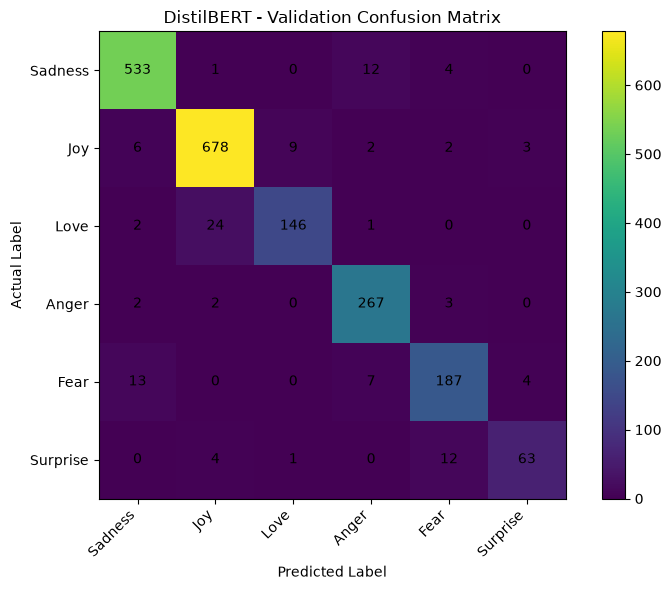

In [25]:
import matplotlib.pyplot as plt

transformer_conf_matrix = confusion_matrix(
    transformer_validation_labels,
    transformer_validation_predictions,
)

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(transformer_conf_matrix)

ax.set_title("DistilBERT - Validation Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

class_names = [
    "Sadness",
    "Joy",
    "Love",
    "Anger",
    "Fear",
    "Surprise",
]

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(class_names)

for i in range(transformer_conf_matrix.shape[0]):
    for j in range(transformer_conf_matrix.shape[1]):
        ax.text(
            j,
            i,
            transformer_conf_matrix[i, j],
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

## 15. Classical Baseline vs Transformer Comparison

The preferred class-weighted Logistic Regression baseline is compared with the best DistilBERT validation checkpoint.

Both models are evaluated using the same cleaned validation dataset and the same primary evaluation metrics.

In [26]:
final_model_comparison = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1-score",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1-score",
        ],
        "Class-Weighted Logistic Regression": [
            0.9024,
            0.8595,
            0.9047,
            0.8788,
            0.9076,
            0.9024,
            0.9035,
        ],
        "DistilBERT": [
            best_validation_metrics["eval_accuracy"],
            best_validation_metrics["eval_macro_precision"],
            best_validation_metrics["eval_macro_recall"],
            best_validation_metrics["eval_macro_f1"],
            best_validation_metrics["eval_weighted_precision"],
            best_validation_metrics["eval_weighted_recall"],
            best_validation_metrics["eval_weighted_f1"],
        ],
    }
)

final_model_comparison["Difference"] = (
    final_model_comparison["DistilBERT"]
    - final_model_comparison[
        "Class-Weighted Logistic Regression"
    ]
)

display(final_model_comparison.round(4))

,Metric,Class-Weighted Logistic Regression,DistilBERT,Difference
0,Accuracy,0.9024,0.9427,0.0403
1,Macro Precision,0.8595,0.9290,0.0695
2,Macro Recall,0.9047,0.9050,0.0003
3,Macro F1-score,0.8788,0.9158,0.0370
4,Weighted Precision,0.9076,0.9423,0.0347
5,Weighted Recall,0.9024,0.9427,0.0403
6,Weighted F1-score,0.9035,0.9420,0.0385


## 16. Development-Stage Model Selection

Based on validation performance, DistilBERT is selected as the preferred model for the next stage of the project.

Compared with the class-weighted Logistic Regression baseline, DistilBERT achieved higher accuracy, macro precision, macro F1-score, weighted precision, weighted recall, and weighted F1-score.

Macro recall remained approximately comparable to the class-weighted baseline, while overall precision and F1 performance improved substantially.

These results indicate that contextual transformer representations provide an advantage over TF-IDF features for this six-class emotion-classification task.

This selection is based only on validation data. The test dataset has remained untouched throughout model development and will be used later for final evaluation of the selected model.

## 17. Save the Selected Transformer Model

The best DistilBERT checkpoint selected using validation macro F1-score is saved together with its tokenizer.

These files will later be used for final testing and integration into the web application.

In [27]:
SELECTED_MODEL_DIR = (
    PROJECT_ROOT / "ml" / "saved_models" / "selected-distilbert-emotion"
)

trainer.save_model(str(SELECTED_MODEL_DIR))
tokenizer.save_pretrained(str(SELECTED_MODEL_DIR))

print("Selected transformer model saved to:")
print(SELECTED_MODEL_DIR)

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.35s/it]

Selected transformer model saved to:
/mnt/c/Final Year Project/emotional-wellbeing-system/ml/saved_models/selected-distilbert-emotion


In [28]:
print("Saved files:")
for file_path in sorted(SELECTED_MODEL_DIR.iterdir()):
    print("-", file_path.name)

Saved files:
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json
- training_args.bin
